In [4]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("novagen_dataset.csv")

In [8]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [19]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(df[categorical_cols])

In [20]:
X_scale

array([[-0.70078478,  1.40658375,  1.75570894, -0.58327569, -0.5813408 ],
       [-0.70078478, -0.71094238,  1.75570894, -0.58327569, -0.5813408 ],
       [ 1.42697162, -0.71094238, -0.56957049, -0.58327569, -0.5813408 ],
       ...,
       [ 1.42697162, -0.71094238,  1.75570894, -0.58327569, -0.5813408 ],
       [ 1.42697162, -0.71094238,  1.75570894, -0.58327569, -0.5813408 ],
       [-0.70078478, -0.71094238,  1.75570894, -0.58327569, -0.5813408 ]],
      shape=(9549, 5))

In [21]:
from sklearn.ensemble import IsolationForest
clf = IsolationForest(n_estimators=200, contamination='auto', random_state=42)

In [22]:
lables = clf.fit_predict(X_scale)

In [23]:
lables

array([-1, -1, -1, ..., -1, -1, -1], shape=(9549,))

In [24]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=2)

Text(0, 0.5, 'pca2')

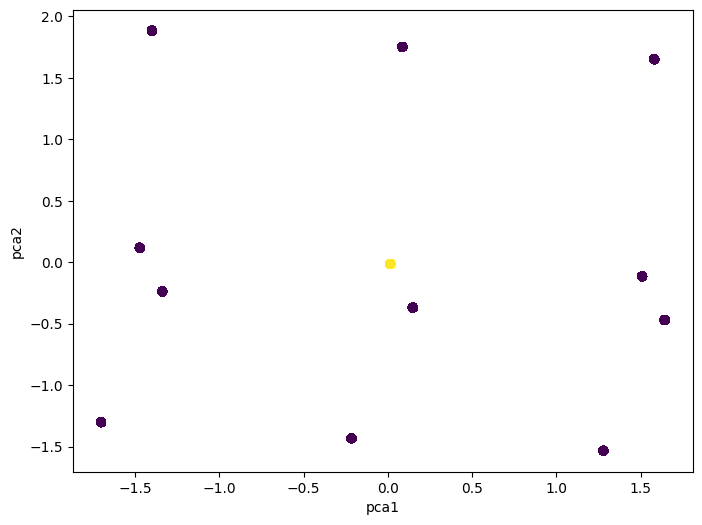

In [25]:
X_pca = pca.fit_transform(X_scale)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=lables)
plt.xlabel("pca1")
plt.ylabel("pca2")